In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [12]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [141]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.': # Iterate over every single character and add '.' at the ending of each
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context), '---->', itos[ix])
        context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y) 

In [142]:
X.shape, X.dtype, Y.shape, Y.dtype, X, Y

(torch.Size([228146, 3]),
 torch.int64,
 torch.Size([228146]),
 torch.int64,
 tensor([[ 0,  0,  0],
         [ 0,  0,  5],
         [ 0,  5, 13],
         ...,
         [26, 26, 25],
         [26, 25, 26],
         [25, 26, 24]]),
 tensor([ 5, 13, 13,  ..., 26, 24,  0]))

In [ ]:
C = torch.randn((27,2))

In [30]:
C[5]

tensor([ 0.5492, -0.5979])

In [ ]:
# eq. --> F.one_hot(torch.tensor(5), num_classes=27).float() @ C

tensor([ 0.5492, -0.5979])

In [41]:
C[X].shape

torch.Size([32, 3, 2])

In [46]:
X[13,2]

tensor(1)

In [44]:
C[X][13,2]

tensor([-4.4859e-04,  4.6917e-01])

In [48]:
emb = C[X]
emb.shape

torch.Size([32, 3, 2])

In [49]:
# Weights and biases
W1 = torch.randn((6,100))
b1 = torch.randn(100)

In [50]:
emb @ W1 + b1

RuntimeError: mat1 and mat2 shapes cannot be multiplied (96x2 and 6x100)

In [59]:
torch.cat([emb[:, 0, :], emb[:, 1, :], emb[:, 2, :]], 1).shape

torch.Size([32, 6])

In [ ]:
torch.cat(torch.unbind(emb, 1), 1).shape # unbind over the first dimension so that it eliminates the 3rd dimensionality

torch.Size([32, 6])

In [62]:
a = torch.arange(18)
a

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17])

In [64]:
a.shape

torch.Size([18])

In [67]:
a.view(3, 3, 2)

tensor([[[ 0,  1],
         [ 2,  3],
         [ 4,  5]],

        [[ 6,  7],
         [ 8,  9],
         [10, 11]],

        [[12, 13],
         [14, 15],
         [16, 17]]])

In [ ]:
a.storage() # How the tensors are computed in the memory

C:\Users\User\AppData\Local\Temp\ipykernel_2348\214256462.py:1: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  a.storage()


 0
 1
 2
 3
 4
 5
 6
 7
 8
 9
 10
 11
 12
 13
 14
 15
 16
 17
[torch.storage.TypedStorage(dtype=torch.int64, device=cpu) of size 18]

In [73]:
emb.shape

torch.Size([32, 3, 2])

In [88]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [89]:
h

tensor([[-0.7925, -0.9998,  0.9826,  ..., -0.9122, -0.9999,  0.9789],
        [ 0.5582, -0.9993,  0.9814,  ..., -0.4150, -0.9269,  0.0836],
        [-0.9936, -0.9460,  1.0000,  ...,  0.9976, -1.0000,  1.0000],
        ...,
        [ 1.0000,  0.9998,  0.9107,  ...,  0.7015,  0.9999,  0.2251],
        [ 0.6574,  0.9401, -0.7278,  ..., -0.6254, -0.9996,  0.9998],
        [ 1.0000, -0.4568, -0.9962,  ..., -0.9887,  0.9997, -0.9999]])

In [90]:
h.shape

torch.Size([32, 100])

In [93]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [94]:
logits = h @ W2 + b2

In [95]:
logits.shape

torch.Size([32, 27])

In [96]:
logits

tensor([[ 1.1786e+01, -2.6921e+00,  6.5630e+00,  4.0521e+00,  7.5875e-01,
         -4.2989e-01,  3.3795e+00,  1.0392e+01,  7.9063e+00, -1.5676e+01,
          7.8451e+00, -8.0863e+00, -7.5203e+00,  6.7378e+00,  1.1520e+01,
         -1.0356e+01, -6.2003e+00, -1.3326e+00, -5.3311e+00,  1.7896e+00,
          9.1523e+00, -5.4660e+00, -5.4652e+00,  4.4481e+00, -1.1318e+01,
          6.0292e+00,  1.7636e+01],
        [ 1.0299e+01, -1.4578e+01, -1.2570e+00, -5.5303e+00,  2.7842e+00,
          2.0202e+00,  1.2463e+00,  9.4688e+00, -8.2571e+00, -7.1898e+00,
          1.3477e+01,  5.2397e+00,  4.1572e-01,  4.4214e+00,  7.7795e+00,
          6.1522e+00, -1.5376e+01,  5.1966e+00, -5.1674e+00, -8.9734e+00,
          5.7585e+00,  4.8146e+00,  8.1819e-01, -5.6824e-01, -2.5756e-01,
         -5.1348e+00,  1.0509e+01],
        [-5.6816e+00, -1.7917e+01, -1.1814e+00, -1.4962e+00,  5.8850e-01,
          2.9797e+00,  5.0521e+00,  7.9539e+00, -5.7777e+00, -1.2355e+00,
          6.2618e+00, -2.2121e+00, -2.18

In [97]:
counts = logits.exp()

In [101]:
prob = counts / counts.sum(1, keepdims=True)

In [99]:
prob.shape

torch.Size([32, 27])

In [100]:
prob[0].sum()

tensor(1.)

In [109]:
loss = -prob[torch.arange(32), Y].log().mean() # The current probabilties as assigned by the NN with this setting of the weights with the correct character in the sequence; Extremely unlikely probabilitities at first
loss

tensor(19.0252)

In [103]:
torch.arange(32)

tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [310]:
# Now lets code
Xtr.shape, Ytr.shape

(torch.Size([182580, 3]), torch.Size([182580]))

In [327]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [289]:
W2 = torch.randn((100, 100), generator=g)
b2 = torch.randn(100, generator=g)
W3 = torch.randn(100, 100, generator=g)
b3 = torch.randn(100, generator=g)
W4 = torch.randn((100, 27))
b4 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2, W3, b3, W4, b4]

In [328]:
sum(p.nelement() for p in parameters) # Nr of params in total

11897

In [218]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [329]:
for p in parameters:
    p.requires_grad = True

In [200]:
lre = torch.linspace(-3, 0, 1000) # 1000 nr between -3 and 0
lrs = 10**lre # exponentially stepped so it becomes 1000 nrs between 0.001 and 1, but non-linearly

In [330]:
lri = []
lossi = []
stepi = []

In [340]:
for i in range(50000):
 
 # minibatch construct
 ix = torch.randint(0, Xtr.shape[0], (64,))

 # forward pass
 emb = C[Xtr[ix]] # (32, 3, 2)
 h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
 #h1 = torch.tanh(h @ W2 + b2)
 logits = h @ W2 + b2
 #logits = h @ W2 + b2 # (32, 27)
 loss = F.cross_entropy(logits, Ytr[ix])
 
 # backward pass
 for p in parameters:
     p.grad = None
 loss.backward()

 # update
 #lr = lrs[i]
 lr = 0.1
 for p in parameters:
     p.data += -lr * p.grad

 # track stats
 #lri.append(lre[i])
 stepi.append(i)
 lossi.append(loss.log10().item())

print(loss.item())


2.1594150066375732


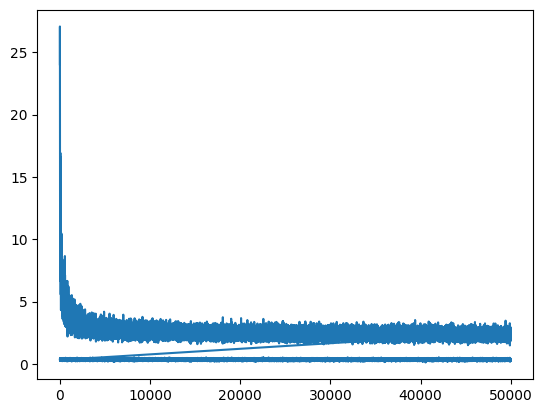

In [337]:
plt.plot(stepi, lossi)

In [338]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev)
loss

tensor(2.2926, grad_fn=<NllLossBackward0>)

In [339]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr)
loss
# as we can see by reading the loss on Xtr and Xdev, the model is underfitting since they are approx. equal

tensor(2.2596, grad_fn=<NllLossBackward0>)

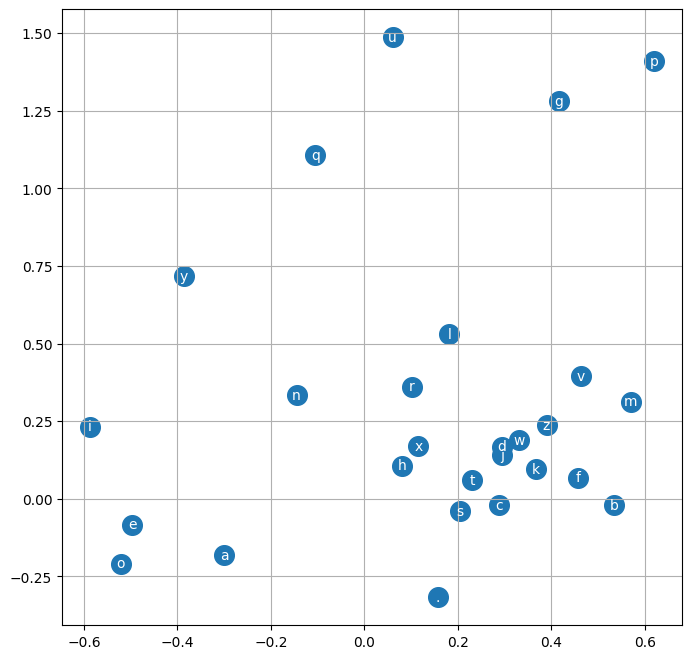

In [326]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha='center', va='center', color='white')
plt.grid('minor')

In [ ]:
logits.max(1) # max along the first dimension

torch.return_types.max(
values=tensor([13.6761, 18.5122, 20.9215, 21.0920, 17.2391, 13.6761, 16.4866, 14.5830,
        16.3272, 18.9422, 16.4938, 21.4498, 13.6761, 17.7255, 17.6910, 20.6486,
        13.6761, 17.0907, 15.7573, 17.6576, 19.0315, 16.5440, 11.3867, 11.1353,
        15.8580, 13.6761, 16.6372, 17.4479, 13.0916, 16.5880, 19.6770, 16.7264],
       grad_fn=<MaxBackward0>),
indices=tensor([19, 13, 13,  1,  0, 19, 12,  9, 22,  9,  1,  0, 19, 22,  1,  0, 19, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0]))

In [140]:
Y

tensor([ 5, 13, 13,  1,  0, 15, 12,  9, 22,  9,  1,  0,  1, 22,  1,  0,  9, 19,
         1,  2,  5, 12, 12,  1,  0, 19, 15, 16,  8,  9,  1,  0])

In [151]:
torch.randint(0, X.shape[0], (32,))

tensor([203576, 171320, 189064,  97833, 148015, 106941, 213505, 127497,  38568,
        157948,  89503, 149465,  26997, 115826,  14348,   2061, 195037, 167673,
        112665,   5103, 130239,  36581, 118947, 224460, 150774, 219545, 175787,
         78208,  53147,  33751,  13611,  51144])

In [299]:
# training split, dev/validation split, test split
# 80%, 10%, 10%

def build_dataset(words):
    block_size = 3 # context length
    X, Y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix] # crop and append

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182580, 3]) torch.Size([182580])
torch.Size([22767, 3]) torch.Size([22767])
torch.Size([22799, 3]) torch.Size([22799])


In [274]:
len(words)

32033

In [276]:
n1, n2

(25626, 28829)

In [ ]:
len(words) - n2 # Nr of eg. for the test set

3204

In [343]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 9)

for _ in range(20):

    out = []
    context = [0] * block_size # initialize with all ...
    while True:
        emb = C[torch.tensor([context])] # (1, block_size, d)
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
    print(''.join(itos[i] for i in out))

zageorga.
lalson.
gan.
maidie.
namin.
esmareah.
cori.
avayonora.
izhavongkpi.
yosseal.
pawzten.
raks.
aima.
khan.
ezozdy.
amaa.
thea.
kobanan.
jala.
celya.
